In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

import ioumatch
from src.pannuke_dataset import PannukePreparedDataset

from models.stardist import StarDist
from models.stardist import stardist_losses
from models.stardist import stardist_decode
from models.stardist import predict_maps

# ---- config
DATA_ROOT = Path("data/prepared/pannuke")
SPLIT = "val"          # ou "train" si tu veux
N_RAYS = 64
N_NUCLEUS_CLASSES = 5
CLAMP_DIST = 80.0

PROB_THR = 0.35
NMS_IOU_THR = 0.3
MIN_AREA = 10
MAX_CANDIDATES = 2000
VOTE_THR = 0.5
LOCAL_MAX_FOOTPRINT = 11

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
def dice_bin(pred: np.ndarray, gt: np.ndarray, eps=1e-6) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = (pred & gt).sum()
    return float((2*inter + eps) / (pred.sum() + gt.sum() + eps))

def iou_bin(pred: np.ndarray, gt: np.ndarray, eps=1e-6) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = (pred & gt).sum()
    union = (pred | gt).sum()
    return float((inter + eps) / (union + eps))

def to_np_img(img_t: torch.Tensor) -> np.ndarray:
    # (3,H,W) float -> (H,W,3)
    x = img_t.detach().cpu().permute(1,2,0).numpy()
    # si ton dataset est déjà [0,1] c'est bon, sinon clip
    return np.clip(x, 0, 1)

def show_triplet(img, a, b, title_a, title_b, cmap_a=None, cmap_b=None):
    plt.figure(figsize=(14,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(a, cmap=cmap_a); plt.title(title_a); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(b, cmap=cmap_b); plt.title(title_b); plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_instances(img, inst, alpha=0.35):
    # inst: (H,W) int32
    m = inst.astype(np.float32)
    m = (m > 0).astype(np.float32)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(m, alpha=alpha)
    plt.axis("off")
    plt.show()


len(ds): 2465

[0] img_002621.npy
instances max id: 8 unique types: [0 1 3]
dist stats FG: mean= 14.611677169799805 max= 80.0


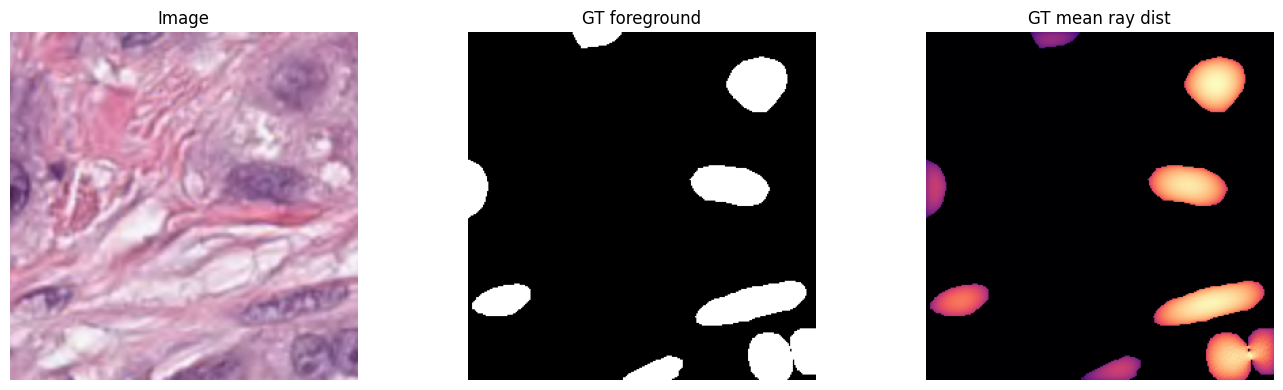


[1] img_002622.npy
instances max id: 10 unique types: [0 1 3]
dist stats FG: mean= 14.095215797424316 max= 80.0


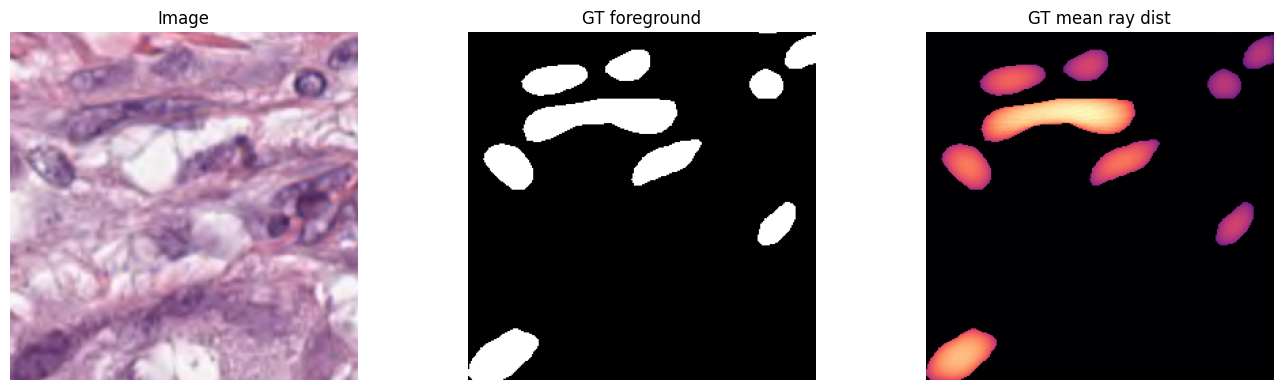


[2] img_002623.npy
instances max id: 9 unique types: [0 1 3]
dist stats FG: mean= 18.353530883789062 max= 80.0


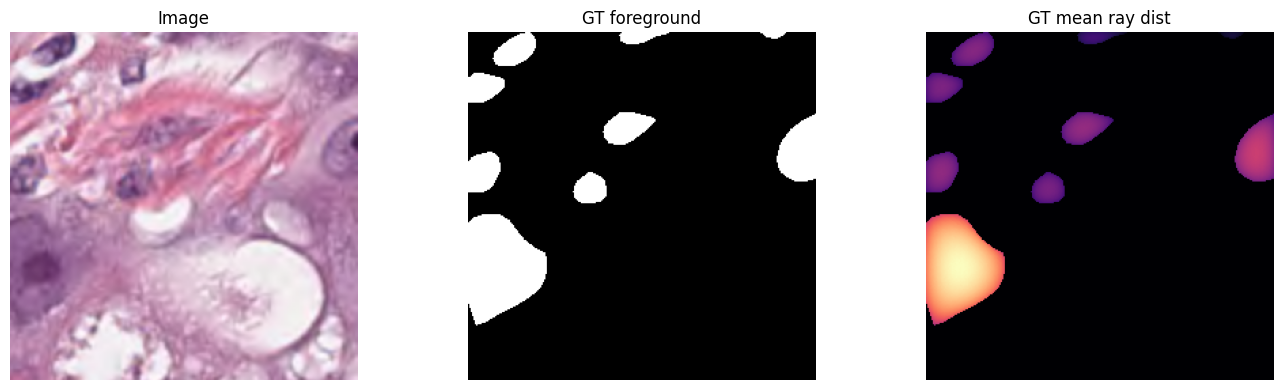

In [3]:
ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=None,
    return_image_name=True,
    load_dists=True,
    n_rays=N_RAYS,
    return_dists=True,   # selon ton impl
)

print("len(ds):", len(ds))

idxs = [0, 1, 2]
for idx in idxs:
    img_t, mask_t, types_t, dist_t, name = ds[idx]

    img = to_np_img(img_t)
    inst = mask_t.cpu().numpy().astype(np.int32)
    types = types_t.cpu().numpy().astype(np.int32)
    dist = dist_t.cpu().numpy().astype(np.float32)  # (R,H,W)

    fg = (inst > 0).astype(np.float32)
    mean_dist = dist.mean(axis=0) * fg

    print(f"\n[{idx}] {name}")
    print("instances max id:", inst.max(), "unique types:", np.unique(types)[:10])
    print("dist stats FG: mean=", float(dist[:, inst>0].mean()) if (inst>0).any() else 0,
          "max=", float(dist[:, inst>0].max()) if (inst>0).any() else 0)

    show_triplet(img, fg, mean_dist, "GT foreground", "GT mean ray dist", cmap_a="gray", cmap_b="magma")


In [4]:
model = StarDist(
    input_ch=3,
    n_rays=N_RAYS,
    n_nucleus_classes=N_NUCLEUS_CLASSES,
    base_ch=32,
    max_dist=CLAMP_DIST,
).to(DEVICE)

model.eval()

img_t, mask_t, types_t, dist_t, name = ds[0]
x = img_t.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    prob_logits, dist_pos, class_logits = model(x)

print("prob_logits:", prob_logits.shape)
print("dist_pos:", dist_pos.shape)
print("class_logits:", class_logits.shape)


prob_logits: torch.Size([1, 1, 256, 256])
dist_pos: torch.Size([1, 64, 256, 256])
class_logits: torch.Size([1, 6, 256, 256])


In [5]:
# build targets comme ton train transform (clamp dist)
fg_t = (mask_t > 0).float().unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1,1,H,W)
d_t = torch.clamp(dist_t.float(), 0.0, CLAMP_DIST).unsqueeze(0).to(DEVICE)  # (1,R,H,W)
cls_t = torch.clamp(types_t.long(), 0, N_NUCLEUS_CLASSES).unsqueeze(0).to(DEVICE)  # (1,H,W)

with torch.no_grad():
    prob_logits, dist_pos, class_logits = model(x)
    losses = stardist_losses(
        prob_logits=prob_logits,
        dist_pos=dist_pos,
        class_logits=class_logits,
        fg_t=fg_t,
        dist_t=d_t,
        cls_t=cls_t,
        w_prob=1.0,
        w_dist=1.0,
        w_ce=0.3,
        w_tversky=0.3,
        pos_weight=10.0,
    )

{k: float(v.detach().cpu()) for k,v in losses.items()}


{'total': 2.9160637855529785,
 'prob': 1.4434208869934082,
 'dist': 0.6457450985908508,
 'ce': 1.8273026943206787,
 'tversky': 0.9290231466293335}

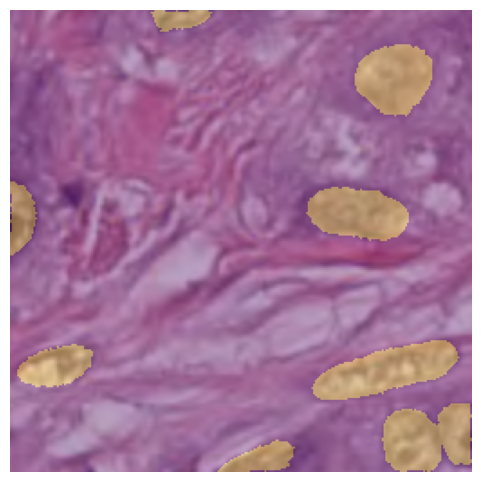

GT decode pred instances: 8 GT instances: 8
F1@0.5: 1.0 TP/FP/FN: 8 0 0


In [6]:
inst = mask_t.cpu().numpy().astype(np.int32)
dist = torch.clamp(dist_t.float(), 0.0, CLAMP_DIST).cpu().numpy().astype(np.float32)

# prob GT peaked (centres plus hauts)
fg = (inst > 0).astype(np.float32)
mean_dist = dist.mean(axis=0)
prob_gt_peak = np.zeros_like(mean_dist, dtype=np.float32)
if fg.any():
    prob_gt_peak = (mean_dist / (mean_dist.max() + 1e-6)) * fg

pred_inst_gt, _ = stardist_decode(
    prob_map=prob_gt_peak,
    dist_map=dist,
    class_prob=None,
    prob_thr=0.3,
    nms_iou_thr=NMS_IOU_THR,
    use_local_maxima=True,
    local_max_footprint=LOCAL_MAX_FOOTPRINT,
    max_candidates=MAX_CANDIDATES,
    min_area=MIN_AREA,
    vote_thr=VOTE_THR,
)

img = to_np_img(img_t)
overlay_instances(img, pred_inst_gt)
print("GT decode pred instances:", int(pred_inst_gt.max()), "GT instances:", int(inst.max()))

res = ioumatch.evaluate_image(pred_inst_gt.astype(np.int32), inst.astype(np.int32),
                             threshold=0.5, method="greedy", inclusive=False, normalize=False)
print("F1@0.5:", res["f1"], "TP/FP/FN:", res["tp"], res["fp"], res["fn"])


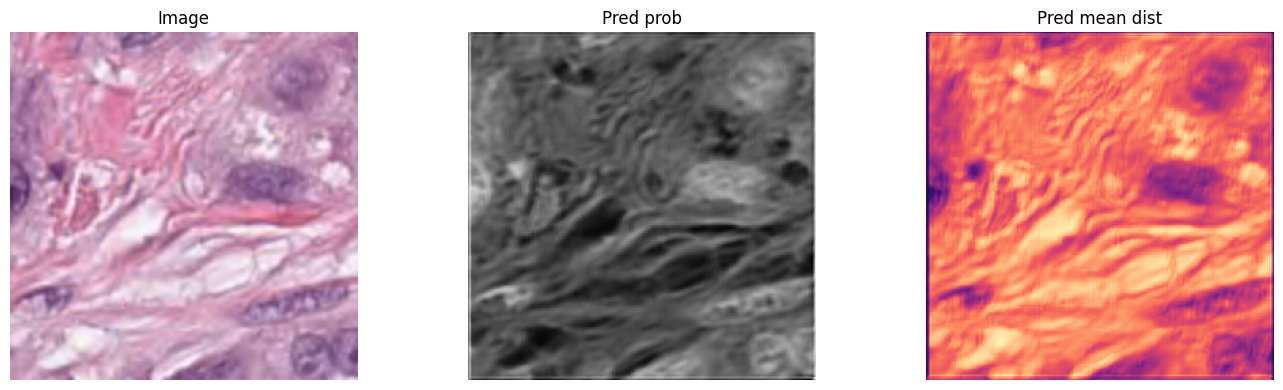

IoU(FG): 0.38186258900054554 Dice(FG): 0.5526780911740046


In [7]:
model.eval()
prob_map, dist_map, cls_prob = predict_maps(model, x, apply_softmax_class=True)

img = to_np_img(img_t)
dist_mean = dist_map.mean(axis=0)
prob = prob_map

show_triplet(img, prob, dist_mean, "Pred prob", "Pred mean dist", cmap_a="gray", cmap_b="magma")

# binary FG comparaison rapide
gt_fg = (inst > 0).astype(np.float32)
pred_fg = (prob >= 0.5).astype(np.float32)
print("IoU(FG):", iou_bin(pred_fg, gt_fg), "Dice(FG):", dice_bin(pred_fg, gt_fg))


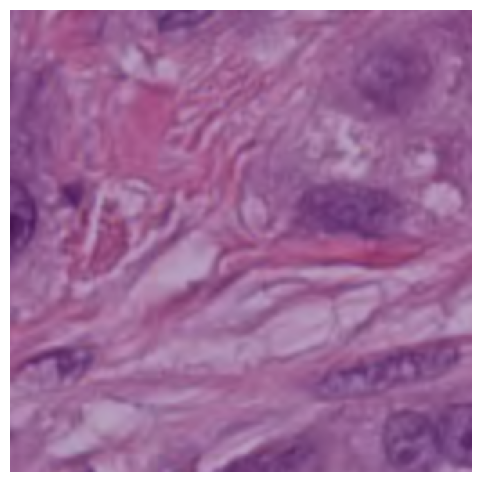

F1@0.5: 0.0 TP/FP/FN: 0 0 8


In [8]:
center = dist_mean
center = center / (center.max() + 1e-6)
prob_peak = prob * center

peak_max = float(prob_peak.max())
prob_thr_final = min(PROB_THR, 0.9 * peak_max)
prob_thr_final = max(prob_thr_final, 0.05)

pred_inst, _ = stardist_decode(
    prob_map=prob_peak,
    dist_map=dist_map,
    class_prob=cls_prob,  # tu peux mettre None si tu veux isoler l’instance-only
    prob_thr=float(prob_thr_final),
    nms_iou_thr=NMS_IOU_THR,
    use_local_maxima=True,
    local_max_footprint=LOCAL_MAX_FOOTPRINT,
    max_candidates=MAX_CANDIDATES,
    min_area=MIN_AREA,
    vote_thr=VOTE_THR,
)

overlay_instances(img, pred_inst)

res = ioumatch.evaluate_image(pred_inst.astype(np.int32), inst.astype(np.int32),
                             threshold=0.5, method="greedy", inclusive=False, normalize=False)
print("F1@0.5:", res["f1"], "TP/FP/FN:", res["tp"], res["fp"], res["fn"])


0 loss: 2.9354019165039062
20 loss: 1.7876832485198975
40 loss: 1.46627676486969
60 loss: 1.1994785070419312
80 loss: 1.05544912815094
100 loss: 0.8721243739128113
120 loss: 0.7602177262306213
140 loss: 0.6664928197860718
160 loss: 0.5888683795928955
180 loss: 0.5207961797714233


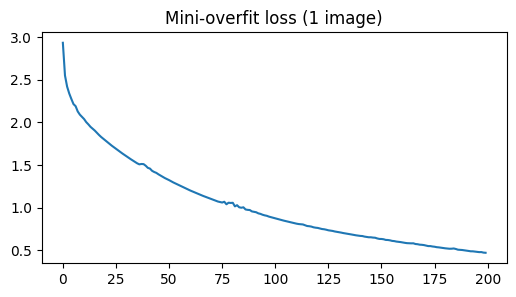

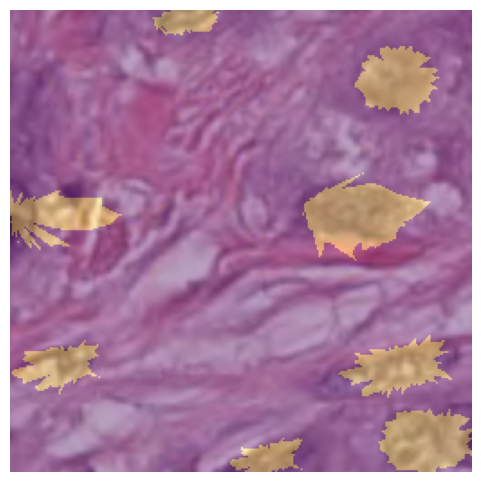

After overfit F1@0.5: 0.875 TP/FP/FN: 7 1 1


In [9]:
model.train()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# fixer un seul sample
img_t, mask_t, types_t, dist_t, name = ds[0]
x = img_t.unsqueeze(0).to(DEVICE)
inst = mask_t.cpu().numpy().astype(np.int32)

fg_t = (mask_t > 0).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
d_t = torch.clamp(dist_t.float(), 0.0, CLAMP_DIST).unsqueeze(0).to(DEVICE)
cls_t = torch.clamp(types_t.long(), 0, N_NUCLEUS_CLASSES).unsqueeze(0).to(DEVICE)

loss_hist = []
for it in range(200):
    opt.zero_grad(set_to_none=True)
    prob_logits, dist_pos, class_logits = model(x)
    losses = stardist_losses(
        prob_logits=prob_logits, dist_pos=dist_pos, class_logits=class_logits,
        fg_t=fg_t, dist_t=d_t, cls_t=cls_t,
        w_prob=1.0, w_dist=1.0, w_ce=0.3, w_tversky=0.3,
        pos_weight=10.0,
    )
    losses["total"].backward()
    opt.step()

    loss_hist.append(float(losses["total"].detach().cpu()))
    if it % 20 == 0:
        print(it, "loss:", loss_hist[-1])

plt.figure(figsize=(6,3))
plt.plot(loss_hist)
plt.title("Mini-overfit loss (1 image)")
plt.show()

model.eval()
prob_map, dist_map, cls_prob = predict_maps(model, x, apply_softmax_class=True)
dist_mean = dist_map.mean(axis=0)
center = dist_mean / (dist_mean.max() + 1e-6)
prob_peak = prob_map * center

pred_inst, _ = stardist_decode(
    prob_map=prob_peak,
    dist_map=dist_map,
    class_prob=None,
    prob_thr=0.3,
    nms_iou_thr=NMS_IOU_THR,
    use_local_maxima=True,
    local_max_footprint=LOCAL_MAX_FOOTPRINT,
    max_candidates=MAX_CANDIDATES,
    min_area=MIN_AREA,
    vote_thr=VOTE_THR,
)

img = to_np_img(img_t)
overlay_instances(img, pred_inst)

res = ioumatch.evaluate_image(pred_inst.astype(np.int32), inst.astype(np.int32),
                             threshold=0.5, method="greedy", inclusive=False, normalize=False)
print("After overfit F1@0.5:", res["f1"], "TP/FP/FN:", res["tp"], res["fp"], res["fn"])


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def overlay_instances(img, inst, alpha=0.45):
    # img: (H,W,3) float or uint8, inst: (H,W) int32
    H,W = inst.shape
    rgb = img.copy()
    if rgb.dtype != np.float32:
        rgb = rgb.astype(np.float32) / 255.0
    lab = inst.astype(np.int32)

    # simple random colors per id (deterministic)
    rng = np.random.default_rng(0)
    colors = rng.random((lab.max()+1, 3), dtype=np.float32)
    colors[0] = 0

    col = colors[lab]
    out = (1-alpha)*rgb + alpha*col
    return np.clip(out, 0, 1)


In [11]:
import torch

# prends EXACTEMENT le même dataset que ton training
ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split="val",
    transform=None,
    return_image_name=True,
    load_dists=True,
    n_rays=N_RAYS,
    return_dists=True,
)

SANITY_IMAGE_INDEX = 0
img_t, mask_t, types_t, dist_t, name = ds[SANITY_IMAGE_INDEX]

print("name:", name)
print("img:", img_t.shape, img_t.dtype, "min/max", float(img_t.min()), float(img_t.max()))
print("mask(inst):", mask_t.shape, mask_t.dtype, "ids", int(mask_t.min()), int(mask_t.max()))
print("types:", types_t.shape, types_t.dtype, "labels", int(types_t.min()), int(types_t.max()))
print("dist:", dist_t.shape, dist_t.dtype, "min/max", float(dist_t.min()), float(dist_t.max()))


name: img_002621.npy
img: torch.Size([3, 256, 256]) torch.float32 min/max 0.12156862765550613 1.0
mask(inst): torch.Size([256, 256]) torch.int64 ids 0 8
types: torch.Size([256, 256]) torch.int64 labels 0 3
dist: torch.Size([64, 256, 256]) torch.float32 min/max 0.0 80.0


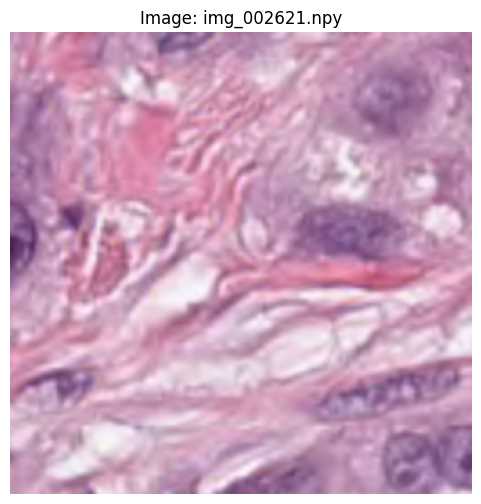

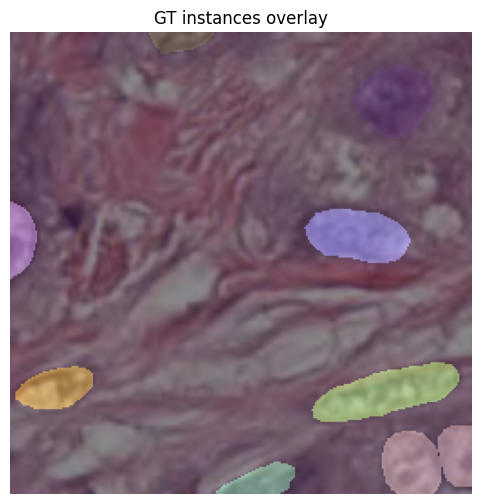

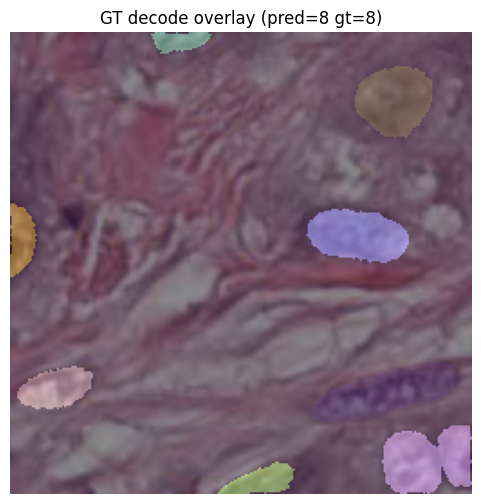

GT decode F1@0.5: 1.0 TP/FP/FN: 8 0 0


In [12]:
from models.stardist import stardist_decode

inst = mask_t.cpu().numpy().astype(np.int32)
dist = torch.clamp(dist_t.float(), 0.0, CLAMP_DIST).cpu().numpy().astype(np.float32)

fg = (inst > 0).astype(np.float32)
mean_dist = dist.mean(axis=0)  # (H,W)
prob_gt_peak = np.zeros_like(mean_dist, dtype=np.float32)
if fg.any():
    prob_gt_peak = (mean_dist / (mean_dist.max() + 1e-6)) * fg

pred_inst_gt, _ = stardist_decode(
    prob_map=prob_gt_peak,
    dist_map=dist,
    class_prob=None,
    prob_thr=0.3,
    nms_iou_thr=NMS_IOU_THR,
    use_local_maxima=True,
    local_max_footprint=LOCAL_MAX_FOOTPRINT,
    max_candidates=MAX_CANDIDATES,
    min_area=MIN_AREA,
    vote_thr=VOTE_THR,
)

img = img_t.permute(1,2,0).cpu().numpy()
show(img, f"Image: {name}")
show(overlay_instances(img, inst), "GT instances overlay")
show(overlay_instances(img, pred_inst_gt), f"GT decode overlay (pred={pred_inst_gt.max()} gt={inst.max()})")

import ioumatch
res = ioumatch.evaluate_image(pred_inst_gt.astype(np.int32), inst.astype(np.int32),
                             threshold=0.5, method="greedy", inclusive=False, normalize=False)
print("GT decode F1@0.5:", res["f1"], "TP/FP/FN:", res["tp"], res["fp"], res["fn"])


=== prob stats ===
prob BG: mean=0.481 p90=0.482 max=0.484
prob FG: mean=0.482 p90=0.482 max=0.484
=== dist stats (FG only) ===
mean_dist_pred FG: mean=14.586 p90=14.589 max=14.600
Random-model decode: pred= 0 gt= 8 prob_thr_final= 0.35 peak_max= 0.4834853708744049


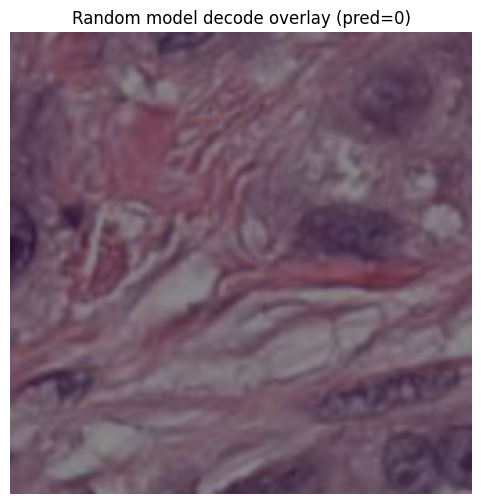

In [13]:
from models.stardist import StarDist, predict_maps, stardist_decode

BASE_CH = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
model = StarDist(input_ch=3, n_rays=N_RAYS, n_nucleus_classes=N_NUCLEUS_CLASSES,
                 base_ch=BASE_CH, max_dist=CLAMP_DIST).to(device).eval()

x = img_t.unsqueeze(0).to(device)

prob_map, dist_map, cls_prob = predict_maps(model, x, apply_softmax_class=True)

# stats foreground vs background
gt_fg = (inst > 0)
bg = ~gt_fg

def stats(arr, m, name):
    if m.sum() == 0:
        print(name, "mask empty")
        return
    v = arr[m]
    print(f"{name}: mean={float(v.mean()):.3f} p90={float(np.percentile(v,90)):.3f} max={float(v.max()):.3f}")

print("=== prob stats ===")
stats(prob_map, bg, "prob BG")
stats(prob_map, gt_fg, "prob FG")

print("=== dist stats (FG only) ===")
stats(dist_map.mean(axis=0), gt_fg, "mean_dist_pred FG")

# ta logique prob_peak (comme ton callback)
center = dist_map.mean(axis=0)
center = center / (center.max() + 1e-6)
prob_peak = prob_map * center

peak_max = float(prob_peak.max())
prob_thr_final = min(float(PROB_THR), 0.9 * peak_max)
prob_thr_final = max(prob_thr_final, 0.05)

pred_inst, _ = stardist_decode(
    prob_map=prob_peak,
    dist_map=dist_map,
    class_prob=cls_prob,
    prob_thr=float(prob_thr_final),
    nms_iou_thr=float(NMS_IOU_THR),
    use_local_maxima=True,
    local_max_footprint=int(LOCAL_MAX_FOOTPRINT),
    max_candidates=int(MAX_CANDIDATES),
    min_area=int(MIN_AREA),
    vote_thr=float(0.8),  # comme epoch<5
)

print("Random-model decode:", "pred=", int(pred_inst.max()), "gt=", int(inst.max()),
      "prob_thr_final=", prob_thr_final, "peak_max=", peak_max)

show(overlay_instances(img, pred_inst), f"Random model decode overlay (pred={pred_inst.max()})")


In [14]:
model.train()
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)


N_RAYS = 64

# PanNuke: types: 0=bg, 1..5=cell types
N_NUCLEUS_CLASSES = 5          # sans background
N_CLASSES_WITH_BG = N_NUCLEUS_CLASSES + 1

BATCH_SIZE = 4
NUM_WORKERS = 4

POS_WEIGHT  = 10.0

LR = 1e-4
BASE_CH = 32

# Loss balancing (paper style: BCE + MAE + CE + Tversky)
W_PROB = 1.0
W_DIST = 1.0
W_CE = 0.3
W_TVERSKY = 0.3
TV_ALPHA = 0.3
TV_BETA = 0.7
TV_INCLUDE_BG = True
LOCAL_MAX_FOOTPRINT = 11

# Stability / target scaling
CLAMP_DIST = 80.0          # pixels
# NORMALIZE_DIST = True
NORMALIZE_DIST = False
NORMALIZE_DIV = 1.0

# Decode
PROB_THR = 0.35
NMS_IOU_THR = 0.3
MIN_AREA = 10
MAX_CANDIDATES = 500
VOTE_THR = 0.5

# Sanity
SANITY_EVERY_N_EPOCHS = 1
SANITY_IOU_THR = 0.5
SANITY_IMAGE_INDEX = 0


# fabrique un target dict comme ton transform (sans aug)
fg_t = (mask_t > 0).float().unsqueeze(0).unsqueeze(0).to(device)         # (1,1,H,W)
d_t  = torch.clamp(dist_t.float(), 0.0, CLAMP_DIST).unsqueeze(0).to(device)  # (1,R,H,W)
c_t  = torch.clamp(types_t.long(), 0, int(N_NUCLEUS_CLASSES)).unsqueeze(0).to(device)  # (1,H,W)

prob_logits, dist_pos, class_logits = model(x)

from models.stardist import stardist_losses
losses = stardist_losses(
    prob_logits=prob_logits,
    dist_pos=dist_pos,
    class_logits=class_logits,
    fg_t=fg_t.type_as(prob_logits),
    dist_t=d_t.type_as(dist_pos),
    cls_t=c_t,
    w_prob=W_PROB, w_dist=W_DIST, w_ce=W_CE, w_tversky=W_TVERSKY,
    tversky_alpha=TV_ALPHA, tversky_beta=TV_BETA, tversky_include_background=TV_INCLUDE_BG,
    pos_weight=POS_WEIGHT,
)

total = losses["total"]
print({k: float(v.detach().cpu()) for k,v in losses.items()})

opt.zero_grad(set_to_none=True)
total.backward()

# check NaN gradients
nan_params = [n for n,p in model.named_parameters() if p.grad is not None and torch.isnan(p.grad).any()]
print("NaN grads:", nan_params[:10], "count=", len(nan_params))

opt.step()
print("one optimizer step OK")


{'total': 3.1015748977661133, 'prob': 1.5160430669784546, 'dist': 0.7053739428520203, 'ce': 2.0022387504577637, 'tversky': 0.9316209554672241}
NaN grads: [] count= 0
one optimizer step OK


In [15]:
import numpy as np
import torch

from models.stardist import predict_maps, stardist_decode

def make_gt_prob_from_gt_dist(gt_inst, gt_dist):
    # prob centrée: mean(dist) normalisée, uniquement dans FG
    gt_fg = (gt_inst > 0).astype(np.float32)
    mean_dist = gt_dist.mean(axis=0)
    mmax = float(mean_dist.max())
    if mmax > 1e-6:
        gt_prob = (mean_dist / mmax) * gt_fg
    else:
        gt_prob = gt_fg
    return gt_prob

def is_flat_map(x, std_thr=1e-3, range_thr=1e-3):
    x = x.astype(np.float32, copy=False)
    return (x.std() < std_thr) or ((x.max() - x.min()) < range_thr)

@torch.no_grad()
def preflight_check(
    model,
    ds,
    idxs=(0,1,2,3,4),
    prob_thr=0.35,
    nms_iou=0.3,
    min_area=10,
    max_candidates=500,
    vote_thr=0.8,
    use_lm=True,
    lm_footprint=11,
    device="cuda",
):
    model.eval()

    report = []
    for i in idxs:
        img_t, inst_t, types_t, dist_t, name = ds[i]  # adapte si ton ds ne renvoie pas name
        x = img_t.unsqueeze(0).to(device)

        prob_map, dist_map, cls_prob = predict_maps(model, x, apply_softmax_class=True)

        gt_inst = inst_t.detach().cpu().numpy().astype(np.int32)
        gt_dist = dist_t.detach().cpu().numpy().astype(np.float32)

        # --- 1) flatness ---
        flat_prob = is_flat_map(prob_map)
        flat_dist = is_flat_map(dist_map.mean(axis=0))

        # --- 2) decode normal (PredProb + PredDist) ---
        center = dist_map.mean(axis=0)
        center = center / (center.max() + 1e-6)
        prob_peak = prob_map * center

        peak_max = float(prob_peak.max())
        prob_thr_final = min(float(prob_thr), 0.9 * peak_max)
        prob_thr_final = max(prob_thr_final, 0.05)

        pred_inst, _ = stardist_decode(
            prob_map=prob_peak,
            dist_map=dist_map,
            class_prob=cls_prob,
            prob_thr=prob_thr_final,
            nms_iou_thr=float(nms_iou),
            use_local_maxima=bool(use_lm),
            local_max_footprint=int(lm_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr),
        )

        # --- 3) ablation GTProb + PredDist (dist head “utilisable”?) ---
        gt_prob = make_gt_prob_from_gt_dist(gt_inst, gt_dist)

        pred_inst_gtprob, _ = stardist_decode(
            prob_map=gt_prob,
            dist_map=dist_map,
            class_prob=cls_prob,
            prob_thr=0.3,  # gt_prob est centrée, threshold plus bas OK
            nms_iou_thr=float(nms_iou),
            use_local_maxima=True,
            local_max_footprint=int(lm_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr),
        )

        report.append({
            "idx": i,
            "name": str(name),
            "gt": int(gt_inst.max()),
            "pred": int(pred_inst.max()),
            "pred_gtprob_preddist": int(pred_inst_gtprob.max()),
            "flat_prob": bool(flat_prob),
            "flat_dist": bool(flat_dist),
            "prob_mean": float(prob_map.mean()),
            "prob_max": float(prob_map.max()),
            "peak_max": float(peak_max),
            "prob_thr_final": float(prob_thr_final),
        })

    return report


In [17]:
import numpy as np
import torch

from models.stardist import predict_maps, stardist_decode


# -----------------------------
# Utils
# -----------------------------
def _is_flat(x: np.ndarray, *, std_thr=1e-3, range_thr=1e-3) -> bool:
    x = x.astype(np.float32, copy=False)
    return (float(x.std()) < std_thr) or (float(x.max() - x.min()) < range_thr)

def _stats(x: np.ndarray, mask: np.ndarray, name: str):
    if mask is None or mask.sum() == 0:
        return {f"{name}_mean": None, f"{name}_p90": None, f"{name}_max": None}
    v = x[mask]
    return {
        f"{name}_mean": float(v.mean()),
        f"{name}_p90": float(np.percentile(v, 90)),
        f"{name}_max": float(v.max()),
    }

def _gt_prob_from_gt_dist(gt_inst: np.ndarray, gt_dist: np.ndarray) -> np.ndarray:
    """
    Build a 'peaked' GT probability map from GT distances.
    Higher in the center, 0 in background. Range ~[0,1].
    """
    fg = (gt_inst > 0).astype(np.float32)
    mean_dist = gt_dist.mean(axis=0)
    md_max = float(mean_dist.max())
    if md_max > 1e-6:
        return (mean_dist / md_max) * fg
    return fg

def _prob_peak_from_pred(prob_map: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    """
    Your current policy: multiply prob by normalized mean distance to prefer centers.
    """
    center = dist_map.mean(axis=0)
    center = center / (float(center.max()) + 1e-6)
    return prob_map * center

def _auto_thr(prob_map: np.ndarray, prob_thr_base: float) -> tuple[float, float]:
    """
    Like your callback: clamp threshold by peak_max.
    Returns (prob_thr_final, peak_max).
    """
    peak_max = float(prob_map.max())
    thr = min(float(prob_thr_base), 0.9 * peak_max)
    thr = max(thr, 0.05)
    return thr, peak_max


# -----------------------------
# Core preflight
# -----------------------------
@torch.no_grad()
def stardist_preflight(
    model,
    ds,
    idxs=(0, 1, 2),
    device=None,
    *,
    prob_thr=0.35,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=500,
    vote_thr_early=0.8,
    vote_thr_late=0.5,
    use_local_maxima=True,
    local_max_footprint=11,
    use_prob_peak=True,
    flat_std_thr=1e-3,
    flat_range_thr=1e-3,
    explode_factor=2.5,   # pred > explode_factor * gt triggers warning
):
    """
    Preflight checks BEFORE training:
      - dataset/decoder sanity via GTProb+GTDist
      - prob head usefulness via PredProb+GTDist
      - dist head usefulness via GTProb+PredDist
      - real decode via PredProb+PredDist
      - flatness checks on prob and dist maps
      - explosion checks on predicted instance count

    Expected dataset item formats:
      - either (img, inst, types, dist, name) OR (img, inst, types, dist)
      - img: (3,H,W) torch float
      - inst: (H,W) torch int (0 bg, >0 instance id)
      - dist: (R,H,W) torch float (gt distances, already clamped ok)

    Returns: list[dict] one per sample.
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device).eval()

    out = []

    for i in idxs:
        item = ds[i]
        if len(item) == 5:
            img_t, inst_t, types_t, dist_t, name = item
        elif len(item) == 4:
            img_t, inst_t, types_t, dist_t = item
            name = f"idx_{i}"
        else:
            raise ValueError(f"Unsupported dataset item length={len(item)}")

        x = img_t.unsqueeze(0).to(device)

        # Forward -> maps
        prob_map, dist_map, cls_prob = predict_maps(model, x, apply_softmax_class=True)

        gt_inst = inst_t.detach().cpu().numpy().astype(np.int32)
        gt_dist = dist_t.detach().cpu().numpy().astype(np.float32)

        fg = (gt_inst > 0)
        bg = ~fg

        # Flatness checks
        flat_prob = _is_flat(prob_map, std_thr=flat_std_thr, range_thr=flat_range_thr)
        flat_dist = _is_flat(dist_map.mean(axis=0), std_thr=flat_std_thr, range_thr=flat_range_thr)

        # Compose prob input (raw or peaked)
        prob_in = _prob_peak_from_pred(prob_map, dist_map) if use_prob_peak else prob_map
        prob_thr_final, peak_max = _auto_thr(prob_in, prob_thr)

        # Vote threshold policy (early vs late)
        vote_thr_use = float(vote_thr_early)

        # ---- Decode helper
        def decode(prob, dist, vote_thr):
            return stardist_decode(
                prob_map=prob,
                dist_map=dist,
                class_prob=cls_prob,
                prob_thr=float(prob_thr_final if prob is prob_in else 0.3 if prob.shape == gt_inst.shape else prob_thr_final),
                nms_iou_thr=float(nms_iou_thr),
                use_local_maxima=bool(use_local_maxima),
                local_max_footprint=int(local_max_footprint),
                max_candidates=int(max_candidates),
                min_area=int(min_area),
                vote_thr=float(vote_thr),
            )[0]  # inst_map

        # --- Sanity: GTProb + GTDist
        gt_prob = _gt_prob_from_gt_dist(gt_inst, gt_dist)
        inst_gt_gt = stardist_decode(
            prob_map=gt_prob,
            dist_map=gt_dist,
            class_prob=None,
            prob_thr=0.3,
            nms_iou_thr=float(nms_iou_thr),
            use_local_maxima=True,
            local_max_footprint=int(local_max_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr_use),
        )[0]

        # --- Ablations
        inst_predprob_gtdist = stardist_decode(
            prob_map=prob_in,
            dist_map=gt_dist,
            class_prob=None,
            prob_thr=float(prob_thr_final),
            nms_iou_thr=float(nms_iou_thr),
            use_local_maxima=bool(use_local_maxima),
            local_max_footprint=int(local_max_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr_use),
        )[0]

        inst_gtprob_preddist = stardist_decode(
            prob_map=gt_prob,
            dist_map=dist_map,
            class_prob=None,
            prob_thr=0.3,
            nms_iou_thr=float(nms_iou_thr),
            use_local_maxima=True,
            local_max_footprint=int(local_max_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr_use),
        )[0]

        # --- Real decode: PredProb + PredDist
        inst_real = stardist_decode(
            prob_map=prob_in,
            dist_map=dist_map,
            class_prob=cls_prob,
            prob_thr=float(prob_thr_final),
            nms_iou_thr=float(nms_iou_thr),
            use_local_maxima=bool(use_local_maxima),
            local_max_footprint=int(local_max_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr_use),
        )[0]

        gt_n = int(gt_inst.max())
        pred_n = int(inst_real.max())

        # Explosion check (only meaningful if gt_n > 0)
        exploded = (gt_n > 0) and (pred_n > explode_factor * gt_n)

        sample = {
            "idx": int(i),
            "name": str(name),
            "gt_instances": gt_n,
            "pred_instances": pred_n,
            "pred_gtprob_preddist": int(inst_gtprob_preddist.max()),
            "pred_predprob_gtdist": int(inst_predprob_gtdist.max()),
            "sanity_gtprob_gtdist": int(inst_gt_gt.max()),
            "flat_prob": bool(flat_prob),
            "flat_dist": bool(flat_dist),
            "exploded": bool(exploded),
            "prob_thr_final": float(prob_thr_final),
            "peak_max": float(peak_max),
            **_stats(prob_map, bg, "prob_bg"),
            **_stats(prob_map, fg, "prob_fg"),
            **_stats(dist_map.mean(axis=0), fg, "pred_meandist_fg"),
            **_stats(gt_dist.mean(axis=0), fg, "gt_meandist_fg"),
        }

        # Human-readable warnings
        warnings = []
        if flat_prob:
            warnings.append("prob_map_flat (random/bug/too-early)")
        if flat_dist:
            warnings.append("dist_map_flat (random/bug/too-early)")
        if sample["sanity_gtprob_gtdist"] != gt_n:
            warnings.append("GT decode mismatch (dataset dists/prob construction/decoder issue)")
        if sample["pred_predprob_gtdist"] == gt_n and sample["pred_gtprob_preddist"] >> 0:
            # optional heuristic, keep light
            pass
        if exploded:
            warnings.append(f"instance_explosion pred={pred_n} vs gt={gt_n} (dist head likely not ready)")
        sample["warnings"] = warnings

        out.append(sample)

    return out


# -----------------------------
# Example usage (copy-paste)
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = StarDist(input_ch=3, n_rays=N_RAYS, n_nucleus_classes=N_NUCLEUS_CLASSES,
                 base_ch=BASE_CH, max_dist=CLAMP_DIST).to(device).eval()

report = stardist_preflight(
    model=model,
    ds=ds,                   # your dataset with return_dists=True
    idxs=(0,1,2,3,4),
    device=device,
    prob_thr=PROB_THR,
    nms_iou_thr=NMS_IOU_THR,
    min_area=MIN_AREA,
    max_candidates=MAX_CANDIDATES,
    vote_thr_early=0.8,
    use_local_maxima=True,
    local_max_footprint=LOCAL_MAX_FOOTPRINT,
    use_prob_peak=True,
)

for r in report:
    print(r["name"], "| gt", r["gt_instances"], "pred", r["pred_instances"], "| warnings:", r["warnings"])


img_002621.npy | gt 8 pred 0 | warnings: ['prob_map_flat (random/bug/too-early)']
img_002622.npy | gt 10 pred 0 | warnings: ['prob_map_flat (random/bug/too-early)', 'GT decode mismatch (dataset dists/prob construction/decoder issue)']
img_002623.npy | gt 9 pred 0 | warnings: ['prob_map_flat (random/bug/too-early)', 'GT decode mismatch (dataset dists/prob construction/decoder issue)']
img_002624.npy | gt 10 pred 0 | warnings: ['prob_map_flat (random/bug/too-early)', 'GT decode mismatch (dataset dists/prob construction/decoder issue)']
img_002625.npy | gt 7 pred 0 | warnings: ['prob_map_flat (random/bug/too-early)', 'GT decode mismatch (dataset dists/prob construction/decoder issue)']
